# Notebook 09 - Uncertainty Quantification (Second version)

City-agnostic improved workflow for **Rome**. This version keeps the original March 2026 `NB09` untouched and adds three targeted improvements:
- spatially explicit daily raster modifiers for trees and waste heat
- event-level warning-day logic for EWS
- EWS CBA uncertainty outputs alongside the impact uncertainty outputs

All new outputs are written to `outputs_variants/masselot_main/rome/tables/uncertainty_improved_fast/` so the original `NB09` outputs remain unchanged.


In [1]:
import os
os.environ["URBAN_HEAT_OUTPUT_VARIANT"] = "masselot_main"
os.environ["IF_MAIN_FAMILY"] = "masselot_tail"


In [2]:
import os
import sys
from pathlib import Path

os.environ.setdefault('CITY', 'rome')
os.environ.setdefault('NB09_N', '512')
os.environ.setdefault('NB09_SEED', '42')
os.environ.setdefault('NB09_MAKE_FIGURES', '0')
os.environ.setdefault('HAZARD_TRACK', 'standard')

def _find_repo_root():
    env = os.environ.get("URBAN_HEAT_ROOT")
    if env:
        root = Path(env).expanduser().resolve()
        if (root / "cityheat").is_dir() and (root / "configs").is_dir():
            return root
    start = Path.cwd().resolve()
    for cand in [start, *start.parents]:
        if (cand / "cityheat").is_dir() and (cand / "configs").is_dir():
            return cand
    raise RuntimeError(
        "Could not locate repo root. Run the notebook from inside the repo "
        "or set URBAN_HEAT_ROOT."
    )

ROOT = _find_repo_root()
output_variant = os.environ.get('URBAN_HEAT_OUTPUT_VARIANT', '').strip()
if not output_variant:
    raise RuntimeError('Masselot-main NB09 requires URBAN_HEAT_OUTPUT_VARIANT.')
OUTPUT_ROOT = ROOT / 'outputs_variants' / output_variant
os.environ.setdefault('MPLCONFIGDIR', str(OUTPUT_ROOT / '.mpl'))
os.environ.setdefault('XDG_CACHE_HOME', str(OUTPUT_ROOT / '.cache'))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)
Path(os.environ['XDG_CACHE_HOME']).mkdir(parents=True, exist_ok=True)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('ROOT:', ROOT)
print('CITY:', os.environ['CITY'])
print('NB09_N:', os.environ['NB09_N'])
print('NB09_SEED:', os.environ['NB09_SEED'])


ROOT: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat
CITY: rome
NB09_N: 512
NB09_SEED: 42


In [3]:
import logging, warnings, os
warnings.filterwarnings('ignore', category=FutureWarning)
for _name in ['climada', 'climada.hazard', 'climada.hazard.base', 'SALib']:
    logging.getLogger(_name).setLevel(logging.ERROR)
print('NB09 Masselot-main full run: city=rome, N=512, seed=42, figures enabled')
print('URBAN_HEAT_OUTPUT_VARIANT=', os.environ.get('URBAN_HEAT_OUTPUT_VARIANT'))
print('IF_MAIN_FAMILY=', os.environ.get('IF_MAIN_FAMILY'))

NB09 Masselot-main full run: city=rome, N=512, seed=42, figures enabled
URBAN_HEAT_OUTPUT_VARIANT= masselot_main
IF_MAIN_FAMILY= masselot_tail


In [4]:
from cityheat.nb09_improved_fast_masselot_main import run_nb09_improved_fast

paths = run_nb09_improved_fast()
paths


[NB09 masselot-main] Run type: masselot_headline_lhs_band — Masselot extrapolation-bracketed LHS over ['masselot_tail', 'masselot']; output dir: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/rome/tables/uncertainty_improved_fast


[rome] sample 1/512: year=2050 aai=0.755


[rome] sample 2/512: year=2040 aai=0.745


[rome] sample 3/512: year=2040 aai=0.692


[rome] sample 4/512: year=2020 aai=0.602


...

[rome] sample 512/512: year=2020 aai=0.002


/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:138: RuntimeWarning: All-NaN slice encountered
  mins = np.nanmin(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:139: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:140: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:141: RuntimeWarning: All-NaN slice encountered
  maxs = np.nanmax(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:138: RuntimeWarning: All-NaN slice encountered
  mins = np.nanmin(p_ind)
/opt/anaconda3/envs/urbanheat

/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:138: RuntimeWarning: All-NaN slice encountered
  mins = np.nanmin(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:139: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:140: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:141: RuntimeWarning: All-NaN slice encountered
  maxs = np.nanmax(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:138: RuntimeWarning: All-NaN slice encountered
  mins = np.nanmin(p_ind)
/opt/anaconda3/envs/urbanheat

/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:138: RuntimeWarning: All-NaN slice encountered
  mins = np.nanmin(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:139: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:140: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:141: RuntimeWarning: All-NaN slice encountered
  maxs = np.nanmax(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:138: RuntimeWarning: All-NaN slice encountered
  mins = np.nanmin(p_ind)
/opt/anaconda3/envs/urbanheat

{'headline_unc_dir': PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/rome/tables/uncertainty_improved_fast'),
 'headline__samples': PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/rome/tables/uncertainty_improved_fast/unc_samples_rome_improved_fast.csv'),
 'samples': PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/rome/tables/uncertainty_improved_fast/unc_samples_rome_improved_fast.csv'),
 'headline__impact': PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/rome/tables/uncertainty_improved_fast/unc_impact_summary_rome_improved_fast.csv'),
 'impact': PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/rome/tables/uncertainty_improved_fast/unc_impact_summary_rome_improved_fast.csv'),
 'headline__fr

In [5]:
import pandas as pd

samples = pd.read_csv(paths['samples'])
samples[[
    'year', 'aai_agg', 'annual_deaths', 'sample_warning_days',
    'sample_threshold_deaths_per_day', 'ews_pv_cost_25y',
    'ews_net_avoided_deaths_25y_cum', 'ews_cost_per_net_death_25y_cum'
]].head(10)

,year,aai_agg,annual_deaths,sample_warning_days,sample_threshold_deaths_per_day,ews_pv_cost_25y,ews_net_avoided_deaths_25y_cum,ews_cost_per_net_death_25y_cum
0,2050,0.755067,275.599307,69.0,1.864130,2.020825e+07,233.533169,86532.658338
1,2040,0.744918,272.640090,60.0,2.704864,5.001500e+06,628.695244,7955.364417
2,2040,0.692045,253.288348,64.0,2.197732,2.063504e+07,457.086367,45144.735275
3,2020,0.602221,220.413047,15.0,3.570005,3.176857e+06,1426.437224,2227.126786
4,2050,0.453940,165.688018,47.0,1.889633,1.084950e+07,108.208005,100265.252080
5,2040,0.341374,124.942719,34.0,2.057310,1.555667e+06,481.049673,3233.900568
6,2050,0.487011,177.759140,66.0,1.310363,3.979016e+06,223.069621,17837.553742
7,2040,0.462471,169.264441,61.0,1.865831,4.951843e+06,756.725427,6543.778391
8,2050,0.656327,239.559207,58.0,2.317225,2.204942e+06,138.810640,15884.528472
9,2020,0.438806,160.602889,30.0,2.129047,4.092036e+06,141.154874,28989.689904


In [6]:
impact_summary = pd.read_csv(paths['impact'])
cba_summary = pd.read_csv(paths['cba'])

display(impact_summary.describe())
display(cba_summary.describe())

,aai_agg,annual_deaths,rp2,rp5,rp10,rp20
count,512.000000,512.000000,512.000000,512.000000,512.000000,512.000000
mean,0.612481,223.845024,0.000020,0.910504,2.748743,3.228142
std,0.191661,69.983537,0.000056,0.427589,0.861323,0.977784
min,0.255738,93.344241,0.000000,0.299360,1.206754,1.457236
25%,0.474669,173.587779,0.000000,0.606633,2.136955,2.525375
50%,0.573317,209.833931,0.000000,0.797509,2.566099,3.039453
75%,0.710556,259.722956,0.000002,1.084461,3.168502,3.740612
max,1.334079,488.272746,0.000338,2.754480,6.289434,7.244026


,ews_pv_cost_25y,ews_net_avoided_deaths_25y_cum,ews_net_avoided_deaths_25y_pv,ews_cost_per_net_death_25y_cum,ews_cost_per_net_death_25y_pv,ews_life_years_saved_25y_cum
count,5.120000e+02,512.000000,512.000000,512.000000,512.000000,512.000000
mean,1.238166e+07,436.781366,275.296978,45014.502393,70692.001742,5606.366030
std,9.821487e+06,341.990387,224.836147,53483.981349,81220.435407,4417.406351
min,8.942962e+05,41.541968,22.320945,2227.126786,3646.057399,569.100009
25%,3.855420e+06,198.020523,120.119130,10442.444041,17707.687782,2563.038341
50%,6.511182e+06,336.023812,209.062573,26129.130483,41296.899066,4255.737488
75%,2.120087e+07,553.180549,353.483867,56634.590087,89925.785287,7109.156278
max,4.020828e+07,2004.916433,1508.101818,334908.639316,501455.660669,26063.752796


## Masselot-main NB09 output paths

- bundle: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/rome/tables/uncertainty_improved_fast/unc_impact_rome_march2026_improved_fast.h5

- bundle_sens: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/rome/tables/uncertainty_improved_fast/unc_impact_rome_march2026_improved_fast_with_sensitivity.h5

- burke_sensitivity_burke_polynomial__bundle: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/rome/tables/uncertainty_burke_sensitivity/burke_polynomial/unc_impact_rome_march2026_improved_fast.h5

- burke_sensitivity_burke_polynomial__bundle_sens: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/rome/tables/uncertainty_burke_sensitivity/burke_polynomial/unc_impact_rome_march2026_improved_fast_with_sensitivity.h5

...

- vuln: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/rome/tables/uncertainty_improved_fast/unc_vulnerability_rome_improved_fast.csv

## Headline sample IF-family counts

,n
if_family,
masselot,256
masselot_tail,256


## Generated headline NB09 figures

### unc_distribution_aai_agg_rome_improved_fast.png

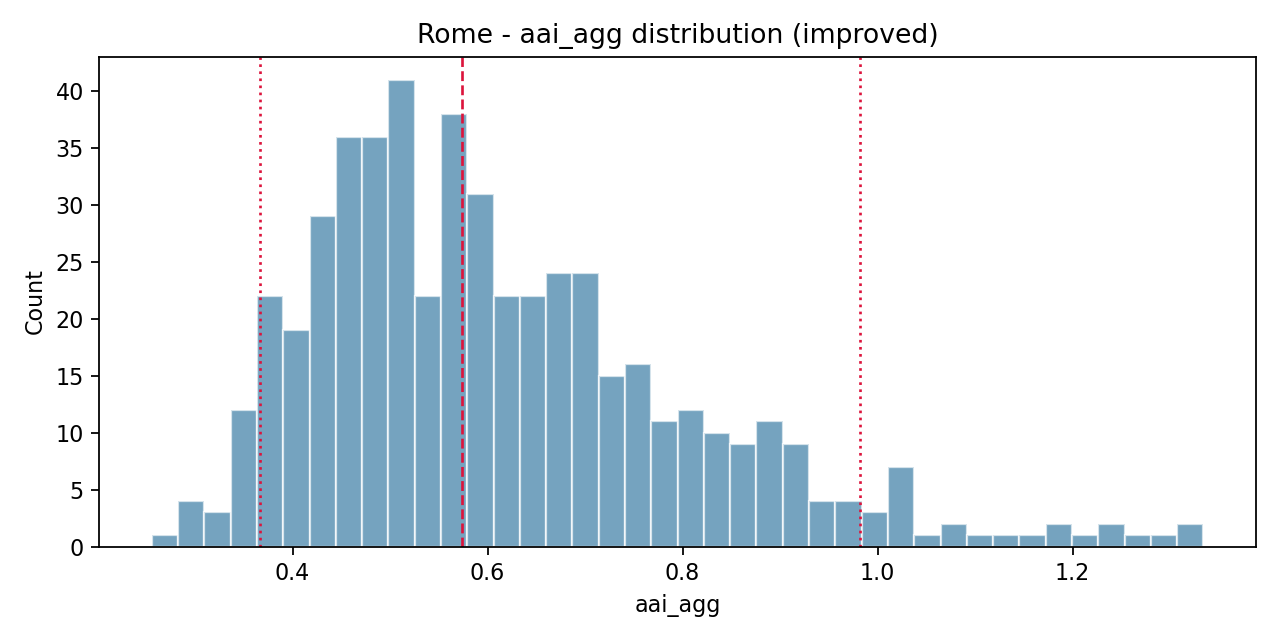

### unc_cdf_aai_agg_rome_improved_fast.png

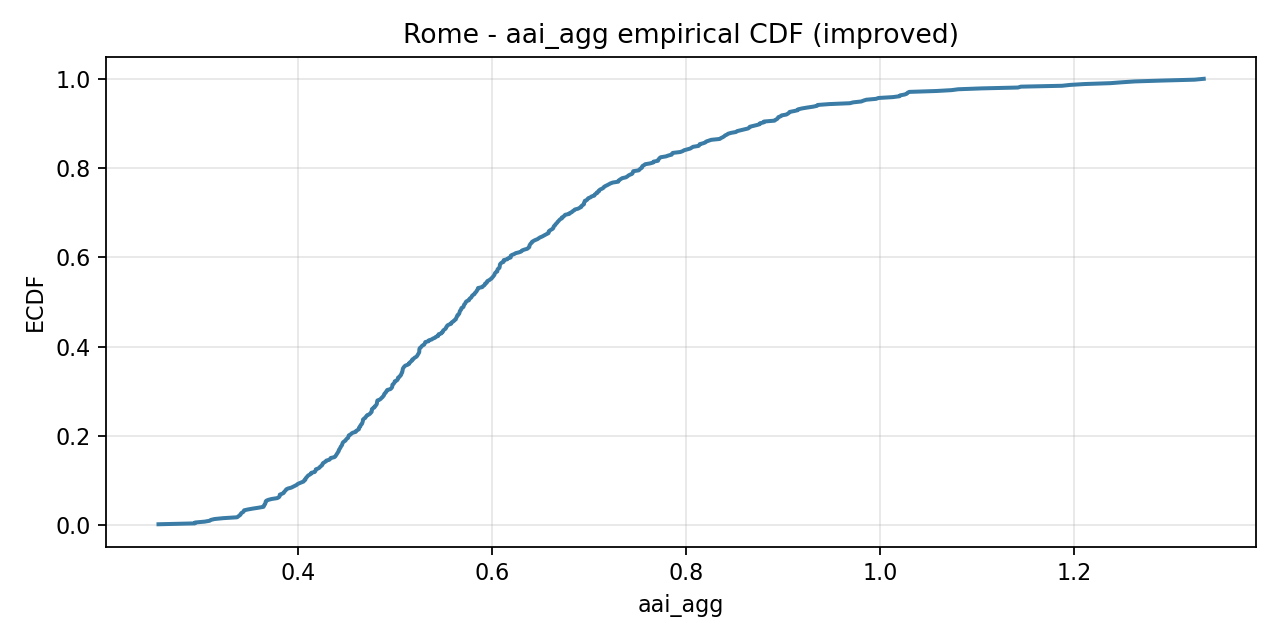

### sens_tornado_aai_agg_rome_improved_fast.png

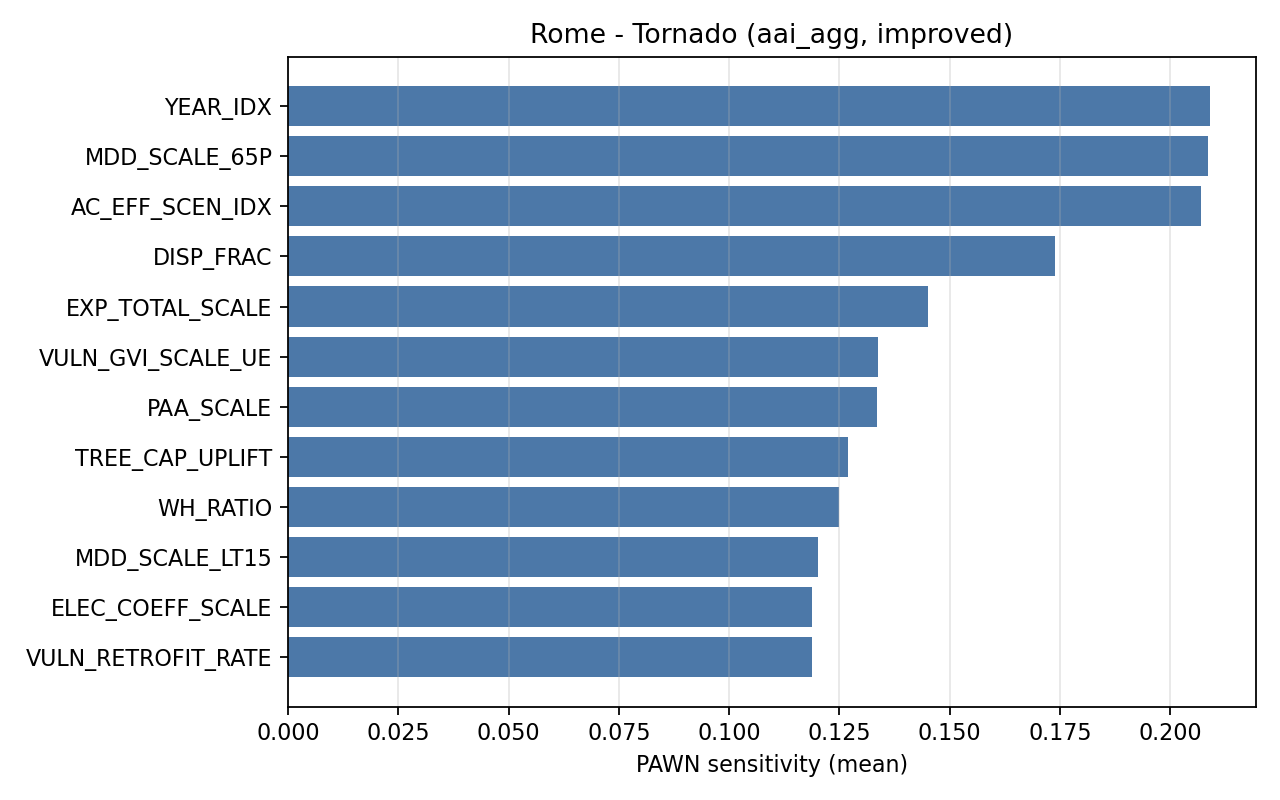

### unc_distribution_cba_ews_rome_improved_fast.png

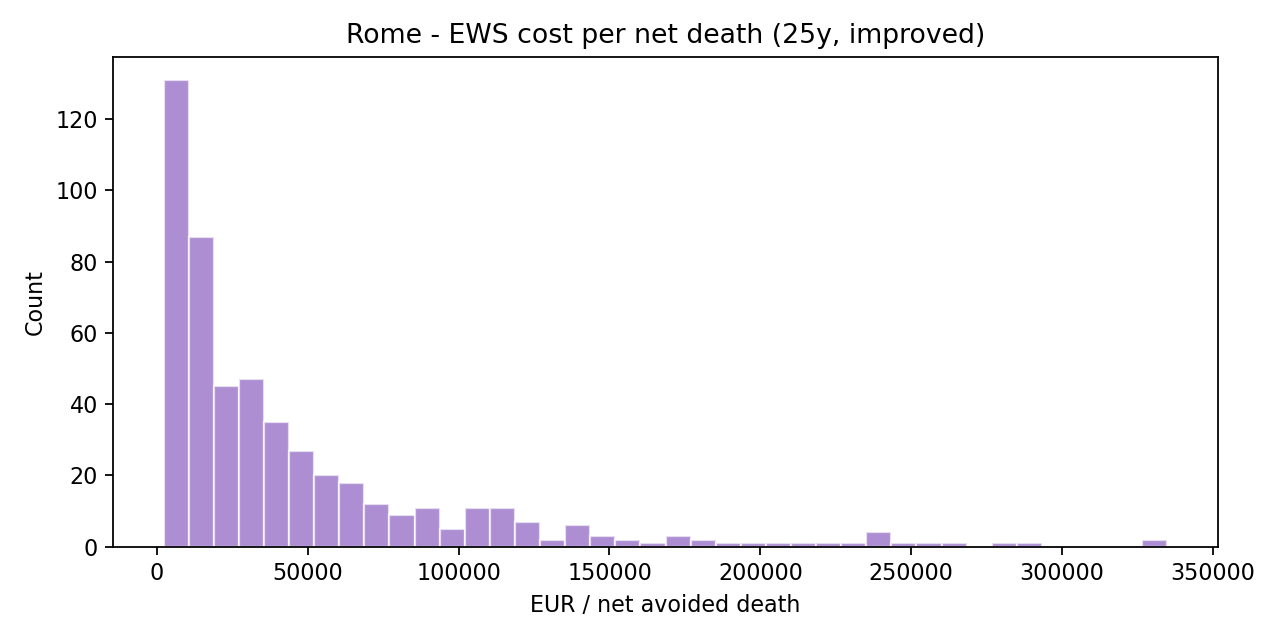

### unc_cdf_cba_ews_rome_improved_fast.png

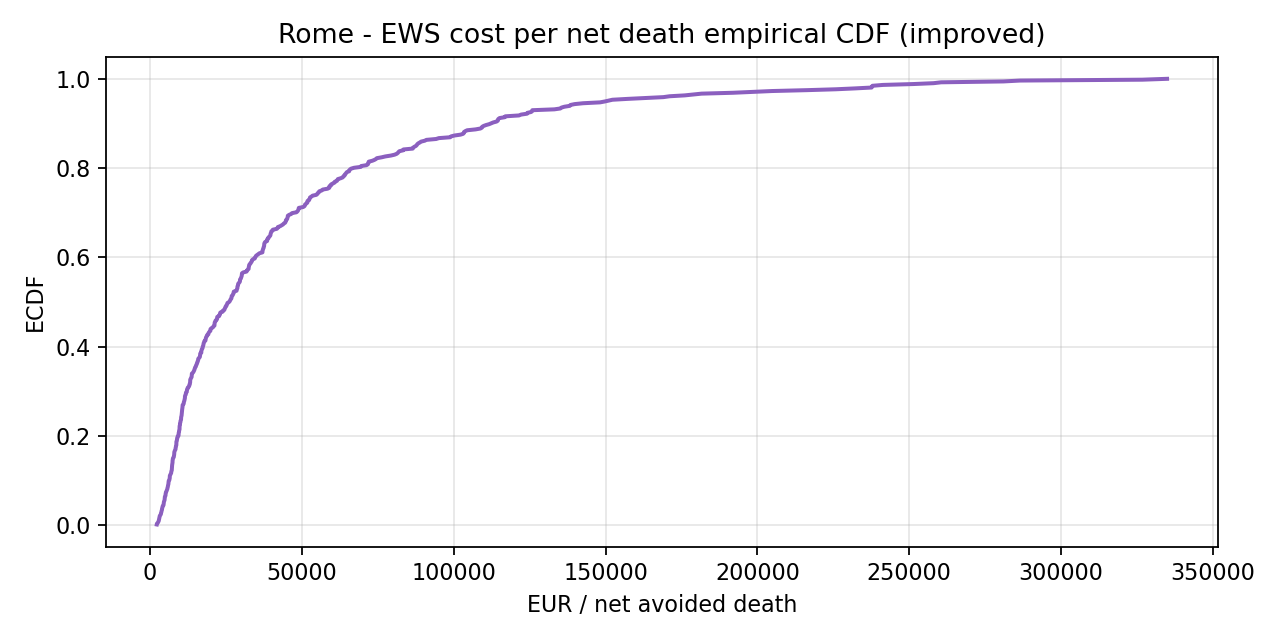

### sens_tornado_cba_ews_rome_improved_fast.png

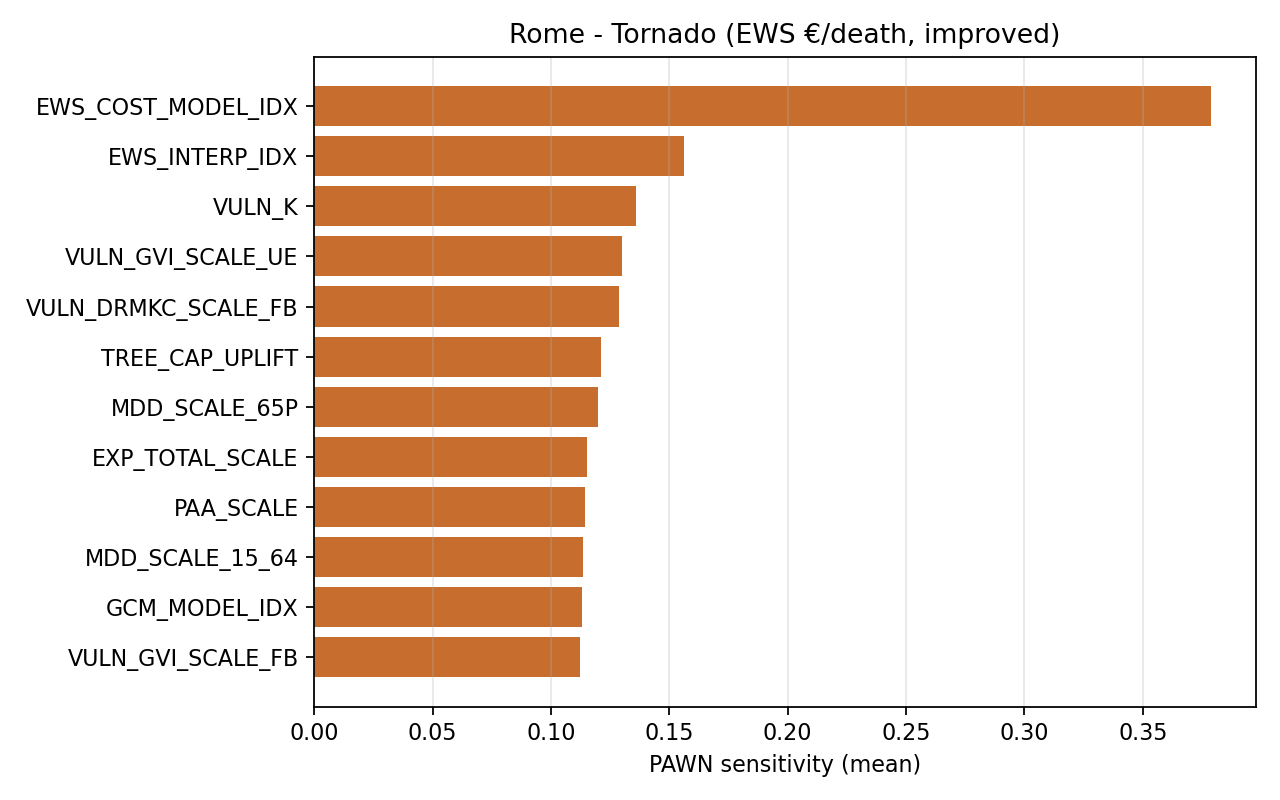

### unc_freq_curve_rome_improved_fast.png

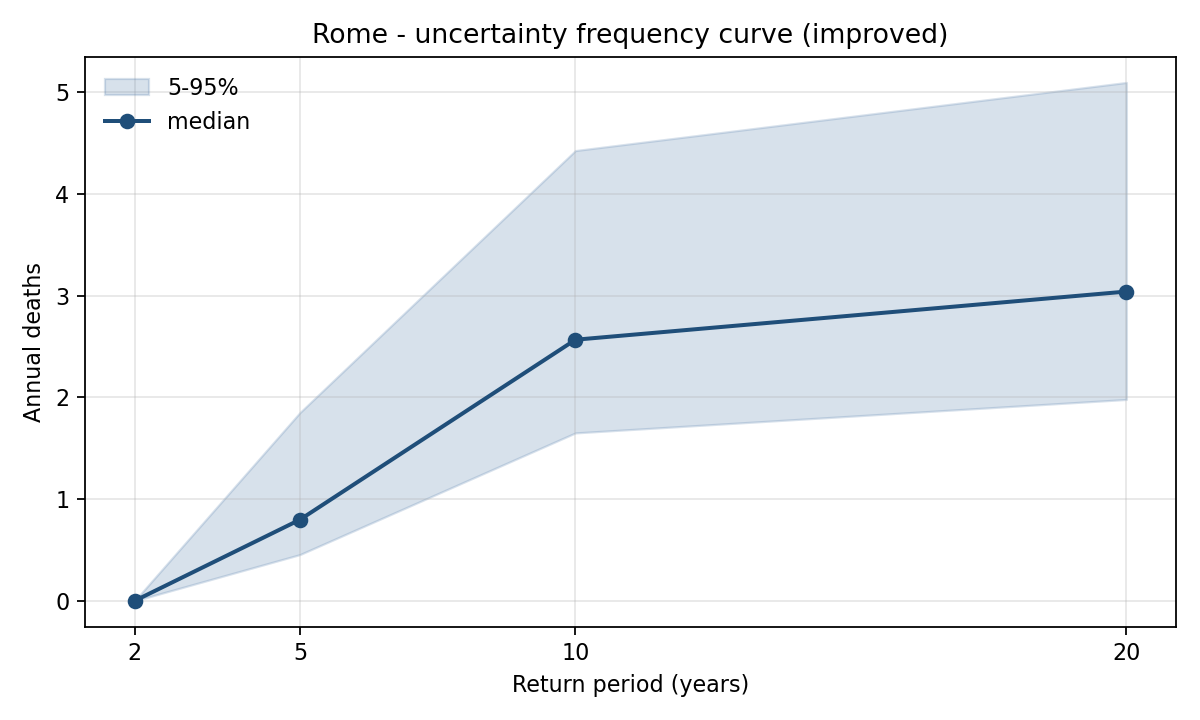

### unc_distribution_vuln_svi_mean_rome_improved_fast.png

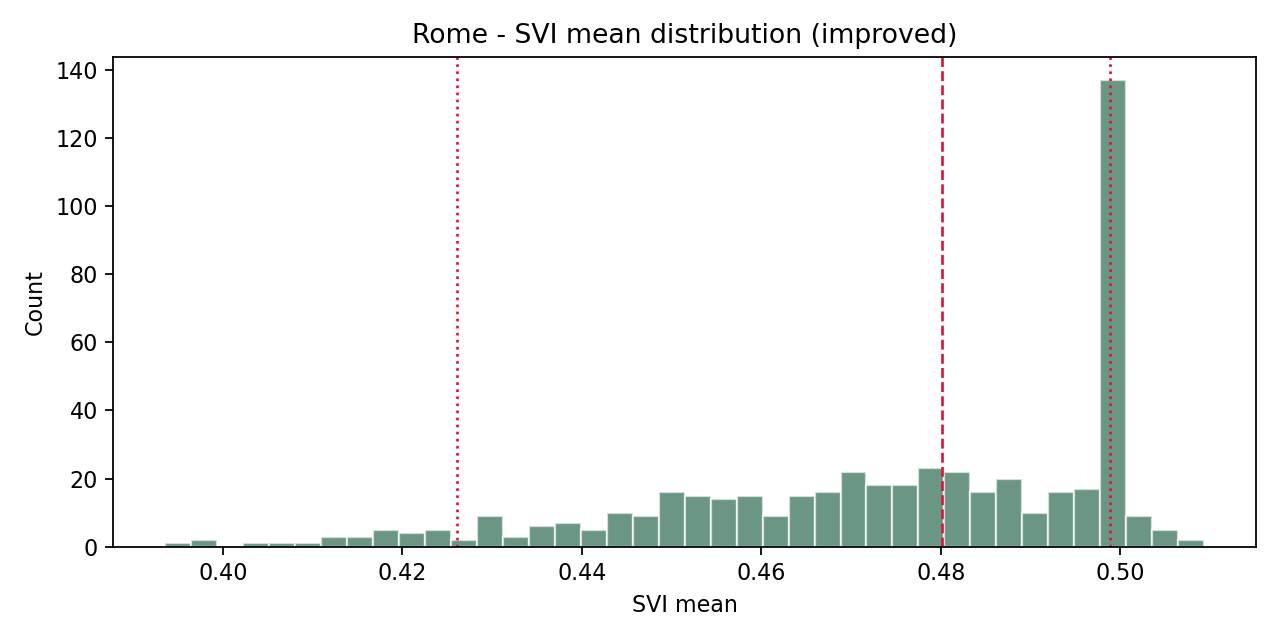

### unc_distribution_vuln_2050_svi_mean_rome_improved_fast.png

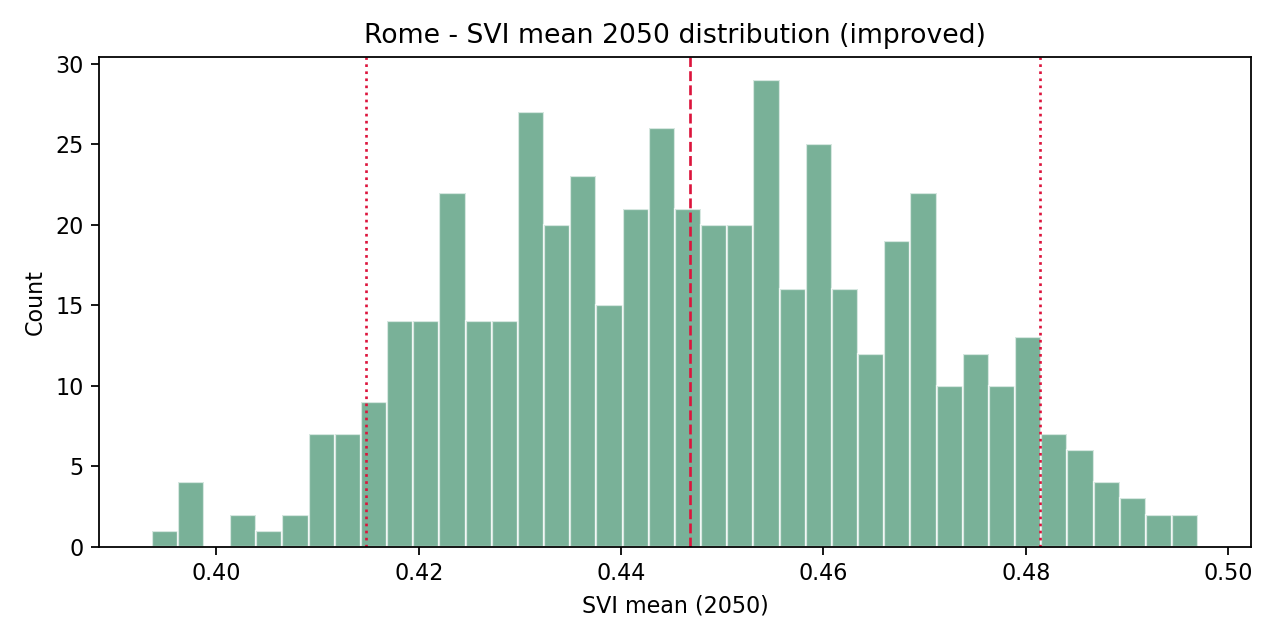

### sens_tornado_vuln_svi_gap_rome_improved_fast.png

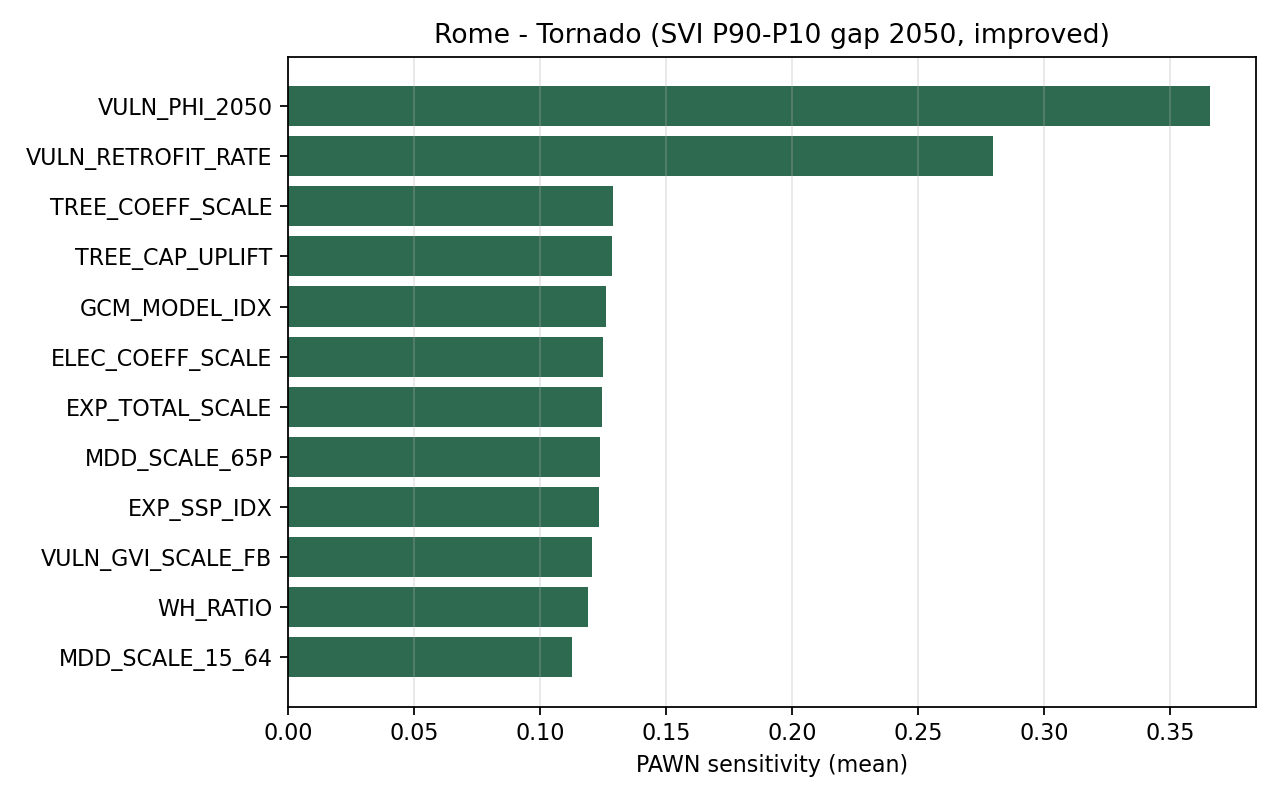

### sens_tornado_vuln_svi_mean_rome_improved_fast.png

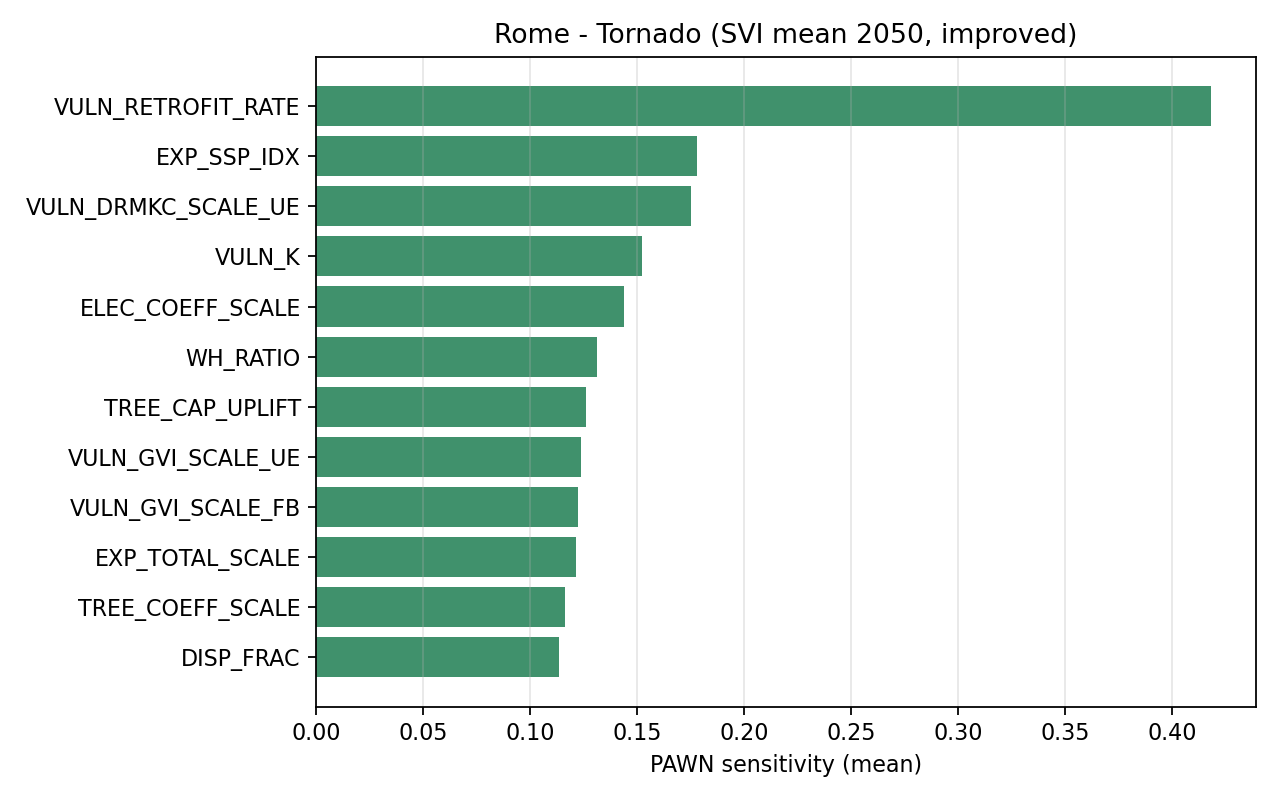

Generated headline figures displayed: 11

In [7]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display

display(Markdown('## Masselot-main NB09 output paths'))
for _k, _v in sorted(paths.items()):
    display(Markdown(f'- {_k}: {_v}'))

samples = pd.read_csv(paths['samples'])
display(Markdown('## Headline sample IF-family counts'))
if 'if_family' in samples.columns:
    display(samples['if_family'].value_counts().rename_axis('if_family').to_frame('n'))

fig_dir = Path(paths['samples']).parent
fig_order = [
    'unc_distribution_aai_agg_rome_improved_fast.png',
    'unc_cdf_aai_agg_rome_improved_fast.png',
    'sens_tornado_aai_agg_rome_improved_fast.png',
    'unc_distribution_cba_ews_rome_improved_fast.png',
    'unc_cdf_cba_ews_rome_improved_fast.png',
    'sens_tornado_cba_ews_rome_improved_fast.png',
    'unc_freq_curve_rome_improved_fast.png',
    'unc_distribution_vuln_svi_mean_rome_improved_fast.png',
    'unc_distribution_vuln_2050_svi_mean_rome_improved_fast.png',
    'sens_tornado_vuln_svi_gap_rome_improved_fast.png',
    'sens_tornado_vuln_svi_mean_rome_improved_fast.png',
]
display(Markdown('## Generated headline NB09 figures'))
shown = 0
for fig_name in fig_order:
    fig_path = fig_dir / fig_name
    if fig_path.exists():
        display(Markdown(f'### {fig_name}'))
        display(Image(filename=str(fig_path)))
        shown += 1
display(Markdown(f'Generated headline figures displayed: {shown}'))